In [1]:
import numpy as np
import math
import time
from tqdm import tqdm
from scipy.linalg import hadamard
import argparse
import matplotlib.pyplot as plt

In [2]:
# converts an index to a Hamming graph position
def ind2sub(ind,K,L):
    if ind == 0:
        return np.zeros(L, dtype=int)
    else:
        mysub = int(np.base_repr(ind,K))
        digits = int(math.log10(mysub))+1
        mysub_str = '0'*(L-digits) + str(mysub)
        unjoined = list(mysub_str)
        return np.array([int(i) for i in unjoined])

# converts a Hamming graph position to an index
def sub2ind(sub,K,L):
    return int(sum(np.multiply(sub,[K**(L-i-1) for i in range(L)])))

In [3]:
K = 2
L = 10
N = 1000
T = 1000
mu = 0.01
trial = 1
dir = 'data'

In [42]:
# recursive function to generate adjacency matrix for hypercube
def make_adj_mat(complete_adj,L):
    temp = complete_adj
    if L > 1:
        n = temp.shape[0]
        temp = np.concatenate((np.concatenate((temp, np.eye(n)), axis=1), np.concatenate((np.eye(n), temp), axis=1)), axis=0)
        return make_adj_mat(temp, L-1)
    else:
        return temp

In [43]:
mu_rate = mu
outdir = dir

In [14]:
## generate fitness landscape
# set up real epistatic vector
epistatic_sparsity = 0.05
J_real_mask = np.random.binomial(1,epistatic_sparsity,size=(K**L))
J_real_sign = 2*np.random.binomial(1,0.5,size=(K**L)) - 1
J_real_magnitude = np.random.normal(10,3,size=(K**L))

J_real = J_real_magnitude * J_real_sign * J_real_mask

# generate real fitness landscape

F_real = np.matmul(hadamard(K**L), J_real) / 1000
F_real -= 3

F_real += -np.min(F_real)
F_real = np.exp(F_real)

print(F_real,np.min(F_real),np.max(F_real))

J_real = K**(-L) * hadamard(K**L) @ F_real

[1.31171488 1.30139765 1.26957888 ... 1.40854198 1.48798075 1.31420366] 1.0 1.7489293154530596


(array([  1.,  14.,  66., 212., 259., 266., 145.,  45.,  14.,   2.]),
 array([1.        , 1.07489293, 1.14978586, 1.22467879, 1.29957173,
        1.37446466, 1.44935759, 1.52425052, 1.59914345, 1.67403638,
        1.74892932]),
 <BarContainer object of 10 artists>)

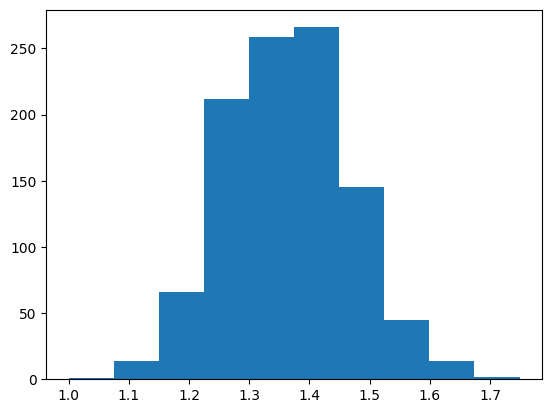

In [15]:
plt.hist(F_real)